<u>A.1) Faça uma biblioteca de constantes de Antoine, para ser usado via Pandas no python.</u>

In [2]:
import pandas as pd


# LEITURA E TRATAMENTO DA BASE DE CONSTANTES
def carregar_base(Tabela_csv):
    df = pd.read_csv(Tabela_csv, sep=';')

    # RENOMEAR COLUNAS
    df = df.rename(columns={
        'Composto': 'composto',
        'Formula': 'formula',
        'Ant(A)': 'A',
        'Ant(B)': 'B',
        'Ant(C)': 'C',
        'Max': 'Tmax',
        'Min': 'Tmin'
    })

    # MUDA VIRGULA PARA PONTO 
    colunas_numericas = ['A', 'B', 'C', 'Tmax', 'Tmin']
    for colunas in colunas_numericas:
        df[colunas] = df[colunas].astype(str).str.replace(',', '.', regex=False)
        df[colunas] = pd.to_numeric(df[colunas], errors='coerce')
           
    df = df.dropna(subset=['A', 'B', 'C']) # REMOVE LINHA EM BRANCO
    df = df.drop_duplicates(subset='composto') # REMOVE LINHA DUPLICADA
    return df

df = carregar_base('../dados/Constantes_Antoine_corrigido.csv')
biblioteca = df.set_index('composto')[['A', 'B', 'C', 'Tmax', 'Tmin']]

biblioteca # EXIBIR A BIBLIOTECA 

,A,B,C,Tmax,Tmin
composto,,,,,
Argon,15.2330,700.51,-5.84,94.0,81.0
Bromide,15.8441,2582.32,-51.56,354.0,259.0
Nitrosyl Cloride,16.9505,2520.70,-23.46,285.0,210.0
Chloride,15.9610,1978.32,-27.01,264.0,172.0
Silicon Tetrachloride,15.8019,2634.16,-43.15,364.0,238.0
...,...,...,...,...,...
n-nonadecane,16.1533,4450.44,-135.60,639.0,456.0
n-pentadecycyclopentane,16.3092,4642.01,-145.10,661.0,476.0
n-eicosane,16.4685,4680.46,-141.10,652.0,471.0


In [3]:
composto = 'Carbon dioxide' # INSIRA O NOME DO COMPOSTO PARA CONSULTA

A, B, C, Tmin, Tmax = biblioteca.loc[composto, ['A', 'B', 'C', 'Tmin', 'Tmax']] # RETORNA O VALOR DAS CONSTANTES

# EXIBIR O VALOR DAS CONsTANTES DE ACORDO COM O COMPOSTO SELECIONADO
pd.DataFrame({
    'Valor': [A, B, C, Tmin, Tmax]
}, index=['A', 'B', 'C', 'Tmin', 'Tmax']).round(3)

,Valor
A,22.59
B,3103.39
C,-0.16
Tmin,154.00
Tmax,204.00


<u>A.2) Faça um código que solicite a maior e menor temperatura e grafique P vs T, coloque lendas, nomes rótulos ,etc

- Cálculo da Pressão de Saturação por Antoine

$$ lnP_{Sat} = A - \frac{B}{T+C} $$

Faixa válida: 63.0 até 100.0 K


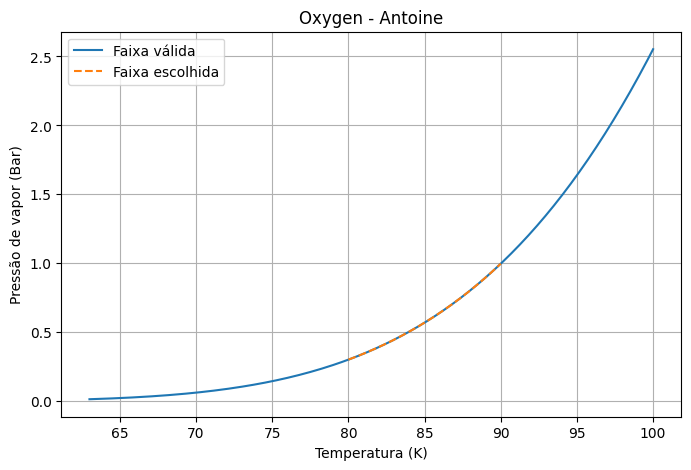

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def pressao_vapor(T, composto, biblioteca):
    A, B, C = biblioteca.loc[composto, ['A', 'B', 'C']]
   
   # CÁLCULO USANDO LOGARÍTMO NATURAL
    return np.exp(A - B / (T + C))

Tmin_tab = biblioteca.loc[composto, "Tmin"]
Tmax_tab = biblioteca.loc[composto, "Tmax"]

print(f"Faixa válida: {Tmin_tab} até {Tmax_tab} K")

Tmin_input = float(input("Digite a temperatura mínima desejada (°C): "))
Tmax_input = float(input("Digite a temperatura máxima desejada (°C): "))

 # INFORMAÇÃO EXTRAIDA DA TABELA
T_tab = np.linspace(Tmin_tab, Tmax_tab, 200)
P_tab = pressao_vapor(T_tab, composto, biblioteca) / 750.1 # CONVERSÃO DE mmHg PARA Bar
 
 # INFORMAÇÃO INSERIDA
T_user = np.linspace(Tmin_input, Tmax_input, 200)
P_user = pressao_vapor(T_user, composto, biblioteca) / 750.1 # CONVERSÃO DE mmHg PARA Bar

# CRIAÇÃO DO GRÁFICO
plt.figure(figsize=(8, 5))
plt.plot(T_tab, P_tab, label="Faixa válida")
plt.plot(T_user, P_user, linestyle='--', label="Faixa escolhida")

 # LEGENDAS
plt.xlabel("Temperatura (K)")
plt.ylabel("Pressão de vapor (Bar)")
plt.title(f"{composto} - Antoine")
plt.legend()
plt.grid(True)
plt.show()


<u>A.3) Mostre seu código comparando graficamente os seguintes compostos, discuta suas observações.</u>

In [4]:
def faixa_auto_grupo(df, itens, margem_C=10):
    mins, maxs = [], []
    for item in itens:
        row, _ = resolver_composto_gnt(df, item)
        if row is not None:
            mins.append(float(row["Tmin"]) - 273.15)
            maxs.append(float(row["Tmax"]) - 273.15)
    if not mins:
        return -150.0, 450.0
    return min(mins) - margem_C, max(maxs) + margem_C


def plotar_grupo(ax, df, titulo, itens, T_C_min=None, T_C_max=None):
    if T_C_min is None or T_C_max is None:
        auto_min, auto_max = faixa_auto_grupo(df, itens, margem_C=10)
        if T_C_min is None: T_C_min = auto_min
        if T_C_max is None: T_C_max = auto_max

    T_C = np.linspace(T_C_min, T_C_max, 500)
    T_K = T_C + 273.15
    observacoes = []
    plotted_any = False

    for item in itens:
        row, label = resolver_composto(df, item)
        if row is None:
            observacoes.append(f"- {label}")
            continue

        A, B, C = float(row["A"]), float(row["B"]), float(row["C"])
        Tmin_K, Tmax_K = float(row["Tmin"]), float(row["Tmax"])
        Tmin_C, Tmax_C = Tmin_K - 273.15, Tmax_K - 273.15

        P_mmHg = antoine_ln_mmHg(T_K, A, B, C)
        P_bar = P_mmHg * 0.00133322
        valido = (T_K >= Tmin_K) & (T_K <= Tmax_K)

        if np.any(valido):
            ax.plot(T_C[valido], P_bar[valido], lw=2, label=label)
            plotted_any = True

        # Se não houver trecho válido, deixa explícito na legenda
        label_extrap = f"{label} (extrap.)" if not np.any(valido) else None
        if np.any(~valido):
            ax.plot(T_C[~valido], P_bar[~valido], lw=1.2, ls="--", alpha=0.45, label=label_extrap)

        observacoes.append(f"- {label}: faixa válida {Tmin_C:.1f} a {Tmax_C:.1f} °C")

    ax.set_title(titulo)
    ax.set_xlabel("Temperatura (°C)")
    ax.set_ylabel("Pressão de vapor (bar)")
    ax.set_yscale("log")
    ax.grid(True, which="both", alpha=0.25)

    if plotted_any or len(itens) > 0:
        ax.legend(fontsize=8, loc="best")

    return observacoes


NameError: name 'resolver_composto_gnt' is not defined

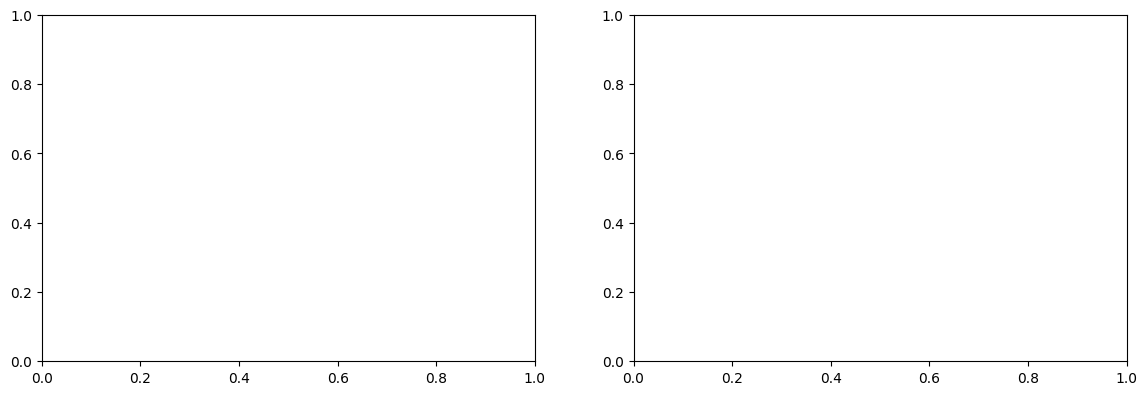

In [5]:
import math
import matplotlib.pyplot as plt

# GARANTE QUE df VEM DA FUNÇÃO QUE RENOMEIA AS COLUNAS
df = carregar_base('../dados/Constantes_Antoine_corrigido.csv')

grupos = [
    # ("Grupo 1: C1 a C6", ["CH4", "C2H6", "C3H8", "C4H10", "C5H12", "C6H14"], None, None),
    ("Grupo 2: Reforming", ["CO", "CO2", "CH4", "H2", "H2O"], None, None),
    # ("Grupo 3: Andrussow", ["CH4", "NH3", "O2", "HCN", "H2O"], 0, 1200),
    # ("Grupo 4: H2O, O2, SO2, SO3, H2SO4", ["H2O", "O2", "SO2", "SO3", "H2SO4"], None, None),
    # ("Grupo 5: C3H8, C3H6, H2", ["C3H8", "C3H6", "H2"], 500, 680),
    # ("Grupo 6: BTX", ["C6H6", "C7H8", "C8H10"], None, None),
    # ("Grupo 7: Benzeno, Hexano, H2", ["C6H6", "C6H14", "H2"], None, None),
]

n = len(grupos)
ncols = 2
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5 * nrows))
axes = axes.flatten()

todas_obs = {}
for i, (titulo, itens, tmin, tmax) in enumerate(grupos):
    todas_obs[titulo] = plotar_grupo(axes[i], df, titulo, itens, tmin, tmax)

for j in range(n, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Comparação de Pressão de Vapor por Antoine (escala log)", fontsize=14)
fig.tight_layout(rect=[0, 0.02, 1, 0.98])
plt.show()

print("Resumo de faixas de temperatura:")
for g, obs in todas_obs.items():
    print(f"\n{g}")
    for o in obs:
        print(o)

<u>B) De suas respostas anteriores compare-as graficamente com as equações de  Lee- Kesler,  Wagner e Riedel. Faça seus comentários e conclusões sobre o comportamento dos modelos ao respeito dos seus compostos comparados.</u>



<table>
<tr>
<td>

- Lee Kesler

$$ lnP_{vapor}= f^{(0)}(T_r)+\omega f^{(1)}(T_r) $$

$$ f^{(0)} = 5.92714 - \frac {6.09648}{T_{r}} - 1.28862 ln T_r + 0.169347 T^6_r $$
$$ f^{(1)} = 15.2518 - \frac {15.6875}{T_{r}} - 13.4721  ln T_r + 0.43577 T^6_r $$

</td>
<td>

- Wagner

$$ lnP_{vPr}= \frac {a\tau + b\tau^{1.5}+c\tau^{2.5}+d\tau^{5}}{T_r}  $$
$$\tau = 1 - T_r $$

</td>
</tr>
</table>

<center>

- Riedel

$$ lnP_{r,\sigma} = A-\frac {B}{T_r}+ClnT_r+DTr^6 $$

 $$ A=-35Q $$
 $$ B= -36Q$$
 $$ C= 42Q + \alpha_c$$
 $$ D=-Q $$

 $$ Q= 0.0838(3.758-\alpha_c)$$
 $$ \alpha_c = \frac{0.315\psi_b+lnP_c}{0.0838\psi_b-lnT_br}$$
 $$ \psi_b = -35 + \frac {3}{T_{br}}+42lnT_{br}- T_{br}^6 $$

 </center>

In [ ]:
from chemicals.identifiers import CAS_from_any # CAS É O CPF DA MOLÉCULA
from chemicals.critical import Tc, Pc
from chemicals.acentric import omega
from chemicals.vapor_pressure import (
    Lee_Kesler,
    Wagner,
    Psat_data_WagnerMcGarry,
    Psat_data_WagnerPoling,
)

def psat_riedel_simplificado(T, Tc_, Pc_, k=5.0):
    T = np.asarray(T, dtype=float)
    Tr = T / Tc_
    return Pc_ * np.exp(k * (1.0 - 1.0 / Tr))

def _buscar_coef_wagner(cas):
    if cas in Psat_data_WagnerMcGarry.index:
        r = Psat_data_WagnerMcGarry.loc[cas]
        return float(r["A"]), float(r["B"]), float(r["C"]), float(r["D"]), "McGarry"
    if cas in Psat_data_WagnerPoling.index:
        r = Psat_data_WagnerPoling.loc[cas]
        return float(r["A"]), float(r["B"]), float(r["C"]), float(r["D"]), "Poling"
    return None

def carregar_biblioteca(csv_path):
    df = pd.read_csv(csv_path, sep=";", decimal=",", encoding="utf-8-sig")
    df = df.rename(columns={"Ant(A)": "A", "Ant(B)": "B", "Ant(C)": "C", "Max": "Tmax", "Min": "Tmin"})

    for c in ["A", "B", "C", "Tmax", "Tmin"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Opção 2: índice por nome do composto
    biblioteca = df.set_index("Composto")[["A", "B", "C", "Tmax", "Tmin"]]
    return biblioteca

def comparar_modelos(composto, biblioteca, n_pontos=200, incluir_riedel=True):
    if composto not in biblioteca.index:
        raise ValueError(f"Composto '{composto}' não encontrado no índice da biblioteca.")

    Tmin, Tmax = biblioteca.loc[composto, ["Tmin", "Tmax"]]
    Tmin, Tmax = float(Tmin), float(Tmax)

    cas = CAS_from_any(composto)
    if cas is None:
        raise ValueError(f"Não foi possível obter CAS para '{composto}'.")

    tc, pc, w = Tc(cas), Pc(cas), omega(cas)
    if any(v is None for v in [tc, pc, w]):
        raise ValueError(f"Falha ao obter propriedades para '{composto}' (CAS {cas}).")

    # GARANTE QUE A FAIXA DE TEMPERATURA ESTÁ DENTRO DOS LIMITES VÁLIDOS PARA OS MODELOS
    if Tmax >= tc:
        Tmax = tc - 1e-6  
    if Tmin <= 0 or Tmin >= Tmax:
        raise ValueError(f"Faixa de T inválida: Tmin={Tmin}, Tmax={Tmax}")

    T_K = np.linspace(Tmin, Tmax, n_pontos)

    P_lk = np.array([Lee_Kesler(float(T), tc, pc, w) for T in T_K])

    coef = _buscar_coef_wagner(cas)
    if coef is None:
        raise ValueError(f"Sem coeficientes de Wagner para CAS {cas}.")
    A, B, C, D, fonte = coef
    P_wg = np.array([Wagner(float(T), tc, pc, A, B, C, D) for T in T_K])

    curvas = {
        "Lee-Kesler": P_lk / 1e5,
        f"Wagner ({fonte})": P_wg / 1e5,
    }

    if incluir_riedel:
        curvas["Riedel"] = psat_riedel_simplificado(T_K, tc, pc) / 1e5

    print(f"Composto: {composto} | CAS: {cas}")
    print(f"Faixa T (K): {T_K.min():.2f} -> {T_K.max():.2f}")
    for nome, p in curvas.items():
        print(f"{nome} (bar): {np.nanmin(p):.6g} -> {np.nanmax(p):.6g}")

    plt.figure(figsize=(9, 5))
    estilos = {"Lee-Kesler": "--", "Riedel": "-."}
    for nome, p in curvas.items():
        ls = estilos.get(nome, ":")
        plt.plot(T_K, p, ls=ls, lw=2, label=nome)

    plt.xlabel("Temperatura (K)")
    plt.ylabel("Pressão de vapor (bar)")
    plt.title(f"Comparação de modelos - {composto}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


csv_path = "Constantes_Antoine_corrigido.csv"
biblioteca = carregar_biblioteca(csv_path)

# INSERIR O NOME DO COMPOSTO PARA COMPARAR OS MODELOS DE PRESSÃO DE VAPOR
comparar_modelos("Water", biblioteca, incluir_riedel=True)
comparar_modelos("Methane", biblioteca, incluir_riedel=True)
comparar_modelos("Hydrogen", biblioteca, incluir_riedel=True)
comparar_modelos("Carbon Monoxide", biblioteca, incluir_riedel=True)

<U> C) Repita seus cálculos para as equações:  GNT  para compostos não polares e GNT compostos com ligações de hidrogênio, compare graficamente estas duas equações e explique seu comportamento. Compare finalmente com a equação de Antoine, comente. </U>

- Gomez-Nieto-Thodos (Compostos Não Polares)

$$ lnP_{r,\sigma} = \beta(\frac{1}{T^m_r}-1)+\gamma(T_r^7-1)   $$

$$T_r = \frac{T}{T_c}$$

$$ T_{br} = \frac {T_b}{T_c} $$

$$ A'= \frac{lnP_c x T_{br}}{1-T_{br}}  $$

$$\gamma = aA'+ b\beta $$

$$ a = \frac {1-\frac{1}{T_{br}}}{T_{br}^7 -1} $$  

$$ b = \frac {1-\frac{1}{T_{br}^m}}{T_{br}^7 -1} $$

$$\beta= -4.267 - \frac {221.79}{A'^{2,5}e^{0.038A'^{2,5}}} + \frac {3.8126}{e^{\frac {2272.44}{A'^{3}}}} $$

$$ m= 0.78425e^{0.089315A'}-\frac{8.5217}{e^{0.74826A'}} $$

- Gomez-Nieto-Thodos (Compostos com Ligação de Hidrogênio)

$$ m = 0,0052M^{0,29}T_c^{0,72} $$

$$ \gamma = \frac {2.44}{M}e^{9,8x10^{-6}}MT_c $$

$$ \beta = \frac {\gamma - aA'}{b}$$


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from chemicals.identifiers import CAS_from_any
from chemicals.critical import Tc, Pc
from chemicals import Tb as Tb_func
from thermo import Chemical


# =============================================================================
# GNT para grupos específicos
# - Não polares: Argon, Hydrogen
# - Ligação de hidrogênio: Water, Hydrogen Fluoride
# =============================================================================

CSV_PATH = "Constantes_Antoine_corrigido.csv"

GRUPOS = [
    ("GNT não polares", ["Argon", "Hydrogen"], "nao_polar"),
    ("GNT ligação de hidrogênio", ["Water", "Hydrogen Fluoride"], "lig. hidrogenio"),
]


# MAPEAMENTO PARA FACILITAR A BUSCA NA BASE
ALIASES = {
    "argon": ["AR", "Argon"],
    "hydrogen": ["H2", "Hydrogen"],
    "water": ["H2O", "Water"],
    "hydrogen fluoride": ["HF", "Hydrogen Fluoride"],
}


def carregar_base(path_csv):
   
    df = pd.read_csv(path_csv, sep=";", decimal=",", encoding="utf-8-sig")

    renomear = {
        "Ant(A)": "A",
        "Ant(B)": "B",
        "Ant(C)": "C",
        "Max": "Tmax",
        "Min": "Tmin",
    }
    df = df.rename(columns=renomear)

    colunas_esperadas = ["Formula", "Composto", "A", "B", "C", "Tmax", "Tmin"]
    faltantes = [c for c in colunas_esperadas if c not in df.columns]
    if faltantes:
        raise ValueError(f"Colunas faltando no CSV: {faltantes}")

    for c in ["A", "B", "C", "Tmax", "Tmin"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    return df


def resolver_composto(df, nome):
    """Localiza uma linha no CSV por fórmula ou nome (case-insensitive)."""
    chaves = [k.lower() for k in ALIASES.get(nome.strip().lower(), [nome])]

    formula = df["Formula"].astype(str).str.strip().str.lower()
    composto = df["Composto"].astype(str).str.strip().str.lower()

    for k in chaves:
        hit = df[(formula == k) | (composto == k)]
        if not hit.empty:
            return hit.iloc[0]

    return None


def get_propriedades(nome):
    """
    Retorna (Tc [K], Pc [Pa], Tb [K], M [g/mol]).
    """
    cas = CAS_from_any(nome)
    tc = Tc(cas)
    pc = Pc(cas)
    tb = Tb_func(cas)
    M = Chemical(cas).MW

    if tc is None or pc is None or tb is None or M is None:
        raise ValueError(f"Propriedades incompletas para {nome}: Tc={tc}, Pc={pc}, Tb={tb}, M={M}")

    return tc, pc, tb, M


def _gnt_A_prime(Pc_Pa, Tbr):
    Pc_atm = Pc_Pa / 101325.0
    return np.log(Pc_atm) * Tbr / (1.0 - Tbr)


def _gnt_a_b(Tbr, m):
    denom = Tbr**7 - 1.0
    a = (1.0 - 1.0 / Tbr) / denom
    b = (1.0 - 1.0 / Tbr**m) / denom
    return a, b


def gnt_nao_polar(T_K, Tc_K, Pc_Pa, Tb_K):
    Tbr = Tb_K / Tc_K
    Ap = _gnt_A_prime(Pc_Pa, Tbr)

    beta = (
        -4.267
        - 221.79 / (Ap**2.5 * np.exp(0.038 * Ap**2.5))
        + 3.8126 / np.exp(2272.44 / Ap**3)
    )

    m = 0.78425 * np.exp(0.089315 * Ap) - 8.5217 / np.exp(0.74826 * Ap)

    a, b = _gnt_a_b(Tbr, m)
    gamma = a * Ap + b * beta

    Tr = T_K / Tc_K
    lnPr = beta * (1.0 / Tr**m - 1.0) + gamma * (Tr**7 - 1.0)

    Pc_atm = Pc_Pa / 101325.0
    return Pc_atm * np.exp(lnPr) * 101325.0


def gnt_hidrogenio(T_K, Tc_K, Pc_Pa, Tb_K, M):
    Tbr = Tb_K / Tc_K
    Ap = _gnt_A_prime(Pc_Pa, Tbr)

    m = 0.0052 * M**0.29 * Tc_K**0.72
    gamma = (2.44 / M) * np.exp(9.8e-6 * M * Tc_K)

    a, b = _gnt_a_b(Tbr, m)
    beta = (gamma - a * Ap) / b

    Tr = T_K / Tc_K
    lnPr = beta * (1.0 / Tr**m - 1.0) + gamma * (Tr**7 - 1.0)

    Pc_atm = Pc_Pa / 101325.0
    return Pc_atm * np.exp(lnPr) * 101325.0


def plotar_grupo(df, titulo, compostos, tipo_gnt):
    fig, ax = plt.subplots(figsize=(9, 5))
    cores = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for i, nome in enumerate(compostos):
        cor = cores[i % len(cores)]
        row = resolver_composto(df, nome)

        if row is None:
            print(f"[AVISO] {nome}: não encontrado na base Antoine")
            continue

        A, B, C = float(row["A"]), float(row["B"]), float(row["C"])
        Tmin_K, Tmax_K = float(row["Tmin"]), float(row["Tmax"])

        if np.isnan(A) or np.isnan(B) or np.isnan(C):
            print(f"[AVISO] {nome}: constantes de Antoine ausentes")
            continue

        T_K = np.linspace(Tmin_K, Tmax_K, 300)
        T_C = T_K - 273.15

        # Antoine: ln(P[mmHg]) = A - B/(T[K] + C)
        P_ant_mmHg = np.exp(A - B / (T_K + C))
        P_ant_bar = P_ant_mmHg * 0.00133322

        ax.plot(T_C, P_ant_bar, color=cor, lw=2.2, label=f"{nome} - Antoine")

        try:
            tc, pc, tb, M = get_propriedades(nome)

            if tipo_gnt == "nao_polar":
                P_gnt_bar = gnt_nao_polar(T_K, tc, pc, tb) / 1e5
                label_gnt = f"{nome} - GNT não polar"
                ls = "--"
            else:
                P_gnt_bar = gnt_hidrogenio(T_K, tc, pc, tb, M) / 1e5
                label_gnt = f"{nome} - GNT Lig. hidrogênio"
                ls = ":"

            ax.plot(T_C, P_gnt_bar, color=cor, lw=1.6, ls=ls, label=label_gnt)

        except Exception as e:
            print(f"[AVISO] {nome}: falha no GNT ({e})")

    ax.set_title(f"{titulo} - Antoine vs GNT", fontsize=12, fontweight="bold")
    ax.set_xlabel("Temperatura (°C)")
    ax.set_ylabel("Pressão de vapor (bar)")
    ax.set_yscale("log")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def main():
    df = carregar_base(CSV_PATH)

    for titulo, compostos, tipo in GRUPOS:
        plotar_grupo(df, titulo, compostos, tipo)


if __name__ == "__main__":
    main()


<u>  D) Para os compostos escolhidos, faça um gráfico P vs T, comparando a equação de Antoine, Lee-Kesler e Wagner, com dados experimentais/reais  e em outro gráfico mostre o erro percentual de cada modelo relativo a seus valores experimentais/reais. </u>

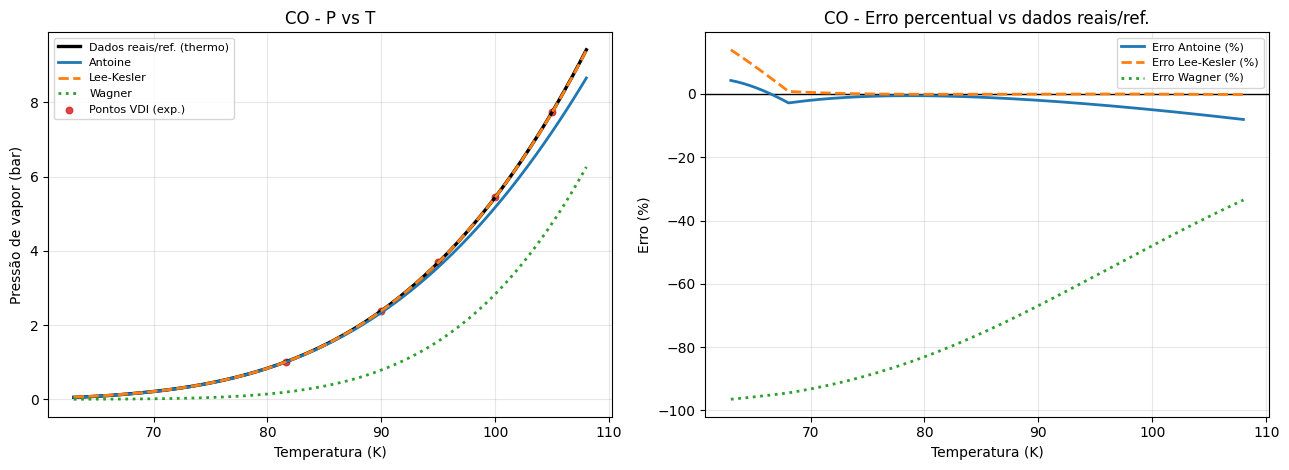

[CO] Faixa T (K): 63.00 a 108.00
[CO] MAPE Antoine:     2.71%
[CO] MAPE Lee-Kesler: 0.96%
[CO] MAPE Wagner:     71.22%


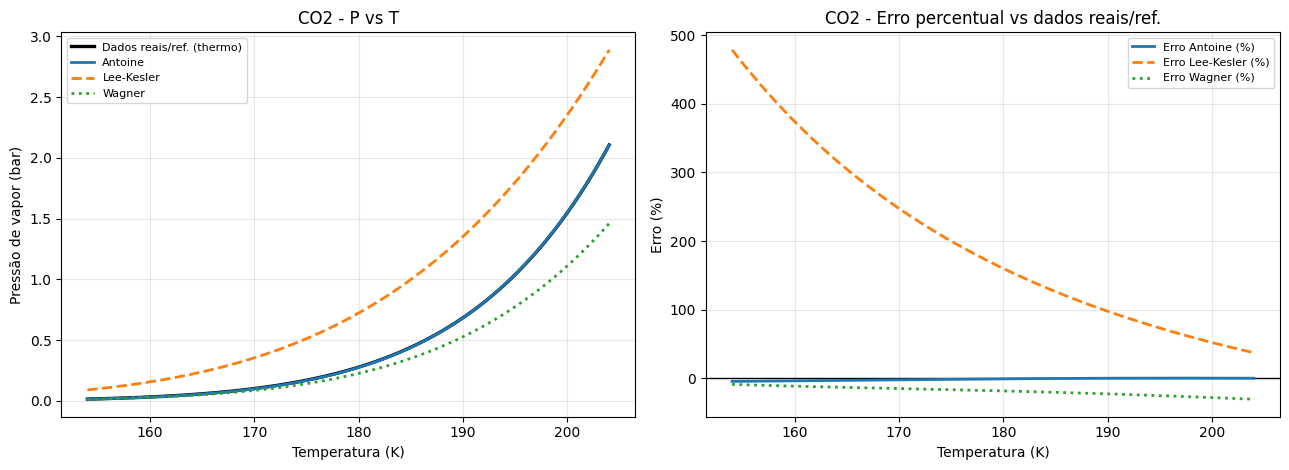

[CO2] Faixa T (K): 154.00 a 204.00
[CO2] MAPE Antoine:     1.51%
[CO2] MAPE Lee-Kesler: 196.41%
[CO2] MAPE Wagner:     18.86%


In [ ]:
from chemicals.vapor_pressure import Lee_Kesler
from chemicals.identifiers import CAS_from_any
from chemicals.critical import Tc, Pc
from chemicals.acentric import omega
from thermo import Chemical

CSV_PATH = 'Constantes_Antoine_corrigido.csv'
COMPOSTOS = ['CO', 'CO2']


def carregar_biblioteca(csv_path=CSV_PATH):
    df = pd.read_csv(csv_path, sep=';', decimal=',')
    df = df.rename(columns={
        'Formula': 'formula',
        'Composto': 'composto',
        'Ant(A)': 'A',
        'Ant(B)': 'B',
        'Ant(C)': 'C',
        'Max': 'Tmax',
        'Min': 'Tmin',
    })
    for col in ['A', 'B', 'C', 'Tmin', 'Tmax']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df['formula'] = df['formula'].astype(str).str.strip()
    df['composto'] = df['composto'].astype(str).str.strip()
    return df


def linha_antoine(df, formula):
    f = formula.upper().strip()

    # Correção da inconsistência da planilha: CO aparece com fórmula "CO2"
    if f == 'CO':
        m = df[df['composto'].str.lower().eq('carbon monoxide')]
        if m.empty:
            raise ValueError('CO não encontrado na base (procure por Carbon Monoxide).')
        return m.iloc[0]

    if f == 'CO2':
        m = df[df['composto'].str.lower().eq('carbon dioxide')]
        if m.empty:
            raise ValueError('CO2 não encontrado na base (procure por Carbon dioxide).')
        return m.iloc[0]

    m = df[df['formula'].str.upper().eq(f)]
    if m.empty:
        raise ValueError(f'{formula} não encontrado na base.')
    return m.iloc[0]


def antoine_bar(T_K, A, B, C):
    # ln(P_mmHg) = A - B/(T + C)
    P_mmHg = np.exp(A - B/(T_K + C))
    return P_mmHg * 0.001333223684  # mmHg -> bar


def wagner_generalizada_bar(T_K, Tc_K, Pc_Pa): # EQUAÇÃO DE WAGNER 
    
    Tr = T_K / Tc_K
    tau = 1.0 - Tr
    A = -7.85951783
    B = 1.84408259
    C = -11.7866497
    D = 22.6807411
    ln_Pr = (A*tau + B*tau**1.5 + C*tau**3 + D*tau**6) / Tr # SOLVE
    return (Pc_Pa * np.exp(ln_Pr)) / 1e5 # DIVIDE PELA PRESSÃO


def referencia_real_bar(T_K, nome_thermo): # REFERÊNCIA REAL/EXP IMPORTADA DA BIBLIOTECA 'THERMO'
    
    chem = Chemical(nome_thermo)
    vp = chem.VaporPressure
    sp = chem.SublimationPressure # ABAIXO DO PONTO TRIPLO DE TEMPERATURA
    T_trip = chem.Tt

    if 'Fit 2023' in sp.all_methods:
        sp_method = 'Fit 2023'
    elif 'LANDOLT' in sp.all_methods:
        sp_method = 'LANDOLT'
    else:
        sp_method = 'PSUB_CLAPEYRON'

    P = np.empty_like(T_K, dtype=float)
    for i, T in enumerate(T_K):
        if T < T_trip:
            P[i] = sp.calculate(float(T), method=sp_method)
        else:
            P[i] = vp.calculate(float(T), method='HEOS_FIT') # HEOS ESTÁ ACIMA DO PONTO TRIPLO 

    return P / 1e5


def plot_composto(formula, df):
    row = linha_antoine(df, formula)
    A, B, C = float(row['A']), float(row['B']), float(row['C'])
    Tmin, Tmax = float(row['Tmin']), float(row['Tmax'])
    T_K = np.linspace(Tmin, Tmax, 250)

    cas = CAS_from_any(formula)
    tc, pc, w = Tc(cas), Pc(cas), omega(cas)

    P_ant = antoine_bar(T_K, A, B, C)
    P_lk = np.array([Lee_Kesler(float(T), tc, pc, w) for T in T_K]) / 1e5
    P_wag = wagner_generalizada_bar(T_K, tc, pc)

    nome_thermo = 'carbon monoxide' if formula == 'CO' else 'carbon dioxide'
    P_ref = referencia_real_bar(T_K, nome_thermo)

    eps = 1e-12
    err_ant = 100.0*(P_ant - P_ref)/(P_ref + eps) # DEFINIÇÃO DO PERCENTUAL DE ERRO
    err_lk = 100.0*(P_lk - P_ref)/(P_ref + eps)
    err_wag = 100.0*(P_wag - P_ref)/(P_ref + eps)

    fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

    # GRAFUCI 1: P vs T
    ax[0].plot(T_K, P_ref, 'k', lw=2.4, label='Dados reais/ref. (thermo)')
    ax[0].plot(T_K, P_ant, label='Antoine', lw=2)
    ax[0].plot(T_K, P_lk, '--', label='Lee-Kesler', lw=2)
    ax[0].plot(T_K, P_wag, ':', label='Wagner', lw=2)

    # PONTO EXPERIMENTAL 
    chem = Chemical(nome_thermo)
    if 'VDI_TABULAR' in chem.VaporPressure.all_methods:
        Ts_vdi, Ps_vdi = chem.VaporPressure.tabular_data['VDI_TABULAR']
        Ts_vdi = np.asarray(Ts_vdi)
        Ps_vdi_bar = np.asarray(Ps_vdi)/1e5
        m = (Ts_vdi >= Tmin) & (Ts_vdi <= Tmax)
        if np.any(m):
            ax[0].scatter(Ts_vdi[m], Ps_vdi_bar[m], s=22, color='tab:red', alpha=0.85,
                          label='Pontos VDI (exp.)')

    ax[0].set_title(f'{formula} - P vs T')
    ax[0].set_xlabel('Temperatura (K)')
    ax[0].set_ylabel('Pressão de vapor (bar)')
    ax[0].grid(alpha=0.3)
    ax[0].legend(fontsize=8)

    # GRAFICO 2: ERRO PERCENTUAL
    ax[1].axhline(0.0, color='k', lw=1)
    ax[1].plot(T_K, err_ant, label='Erro Antoine (%)', lw=2)
    ax[1].plot(T_K, err_lk, '--', label='Erro Lee-Kesler (%)', lw=2)
    ax[1].plot(T_K, err_wag, ':', label='Erro Wagner (%)', lw=2)
    ax[1].set_title(f'{formula} - Erro percentual vs dados reais/ref.')
    ax[1].set_xlabel('Temperatura (K)')
    ax[1].set_ylabel('Erro (%)')
    ax[1].grid(alpha=0.3)
    ax[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    def mape(x):
        return float(np.nanmean(np.abs(x)))

    print(f'[{formula}] Faixa T (K): {Tmin:.2f} a {Tmax:.2f}')
    print(f'[{formula}] MAPE Antoine:     {mape(err_ant):.2f}%')
    print(f'[{formula}] MAPE Lee-Kesler: {mape(err_lk):.2f}%')
    print(f'[{formula}] MAPE Wagner:     {mape(err_wag):.2f}%')


def main():
    df = carregar_biblioteca(CSV_PATH)
    for comp in COMPOSTOS:
        plot_composto(comp, df)


if __name__ == '__main__':
    main()
